<a href="https://colab.research.google.com/github/Vasil8/Quantized-ViT-Robustness/blob/main/Quantized%20ViT%20Robustness%20Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/Vasil8/Quantized-ViT-Robustness.git

Cloning into 'Quantized-ViT-Robustness'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 37.3 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

/tmp/ipython-input-2976/3506187378.py:268: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=config['use_amp'])
train:   0%|          | 0/1563 [00:00<?, ?it/s]/tmp/ipython-input-2976/3506187378.py:305: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=config['use_amp']):
val:   0%|          | 0/157 [00:00<?, ?it/s]/tmp/ipython-input-2976/3506187378.py:310: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=config['use_amp']):
val: 100%|██████████| 157/157 [00:09<00:00, 16.01it/s]


Size of FP32: 82.99 MB
Size of Full_INT8: 22.21 MB
Size of Hybrid_INT8: 52.72 MB


Adversarial (eps=0.05): 100%|██████████| 157/157 [02:51<00:00,  1.09s/it]


                            clean  eps=0.001  eps=0.005  eps=0.01  eps=0.03  \
FP32                       0.7889     0.7591     0.6311    0.4641    0.1267   
Full INT8                  0.7880     0.7585     0.6322    0.4641    0.1269   
Hybrid (blocks 6-11 INT8)  0.7891     0.7583     0.6316    0.4646    0.1278   

                           eps=0.05  
FP32                         0.0503  
Full INT8                    0.0508  
Hybrid (blocks 6-11 INT8)    0.0502  


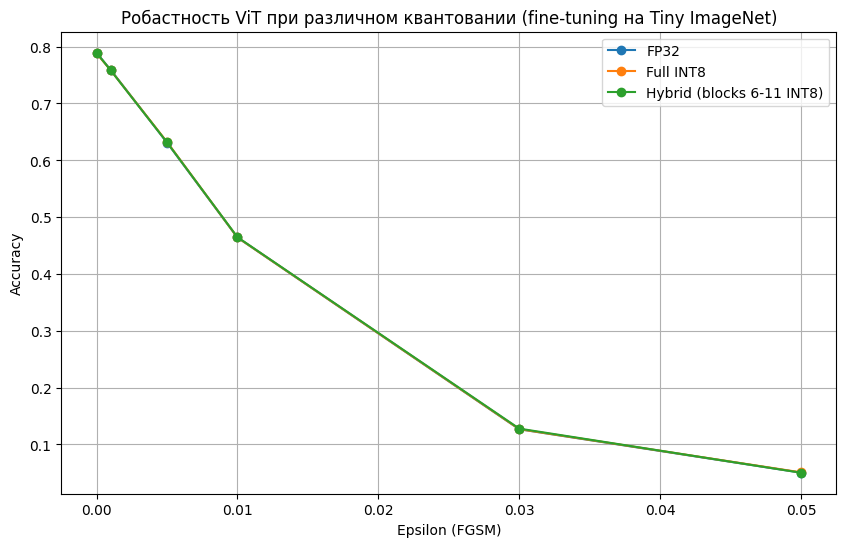

In [ ]:
# ============================================
# 1. Установка библиотек (выполнить в Colab)
# ============================================
!pip install timm foolbox torchao

# ============================================
# 2. Импорты
# ============================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader, Subset
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

import timm
from timm.data import create_transform, resolve_data_config

import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import platform
import hashlib
import uuid
from datetime import datetime, timezone
import random
import json
import logging
from tqdm import tqdm
import foolbox as fb
import subprocess
import zipfile

# Новые импорты из torchao
from torchao.quantization import quantize_
from torchao.quantization.quant_api import int8_dynamic_activation_int8_weight, int4_weight_only

# ============================================
# 2.5. Настройка окружения Hugging Face
# ============================================
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["HF_TOKEN"] = ""  # для публичных моделей токен не нужен
# При необходимости зеркало:
# os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"

# ============================================
# 3. Конфигурация: общая часть + 3 независимых варианта прогона
# ============================================
# Общие параметры данных, обучения, оценки и воспроизводимости (без ветки FP32/INT8/hybrid).
CONFIG_SHARED = {
    'seed': 42,
    'data_root': 'tiny-imagenet-200',
    'batch_size': 64,
    'num_workers': 4,
    'pin_memory': True,
    'prefetch_factor': 2,
    'persistent_workers': True,
    'num_epochs': 10,
    'lr_head': 1e-4,
    'lr_base': 2e-5,
    'weight_decay': 0.05,
    'weight_decay_head': 0.01,
    'warmup_epochs': 3,
    'early_stopping_patience': 3,
    'use_amp': True,
    'tf32': True,
    'epsilons': [0.001, 0.005, 0.01, 0.03, 0.05],
    'use_subset': False,
    'train_subset_size': 500,
    'val_subset_size': 200,
    'model_name': 'vit_small_patch16_224.augreg_in21k_ft_in1k',
    'num_classes': 200,
    'hybrid_quantize_blocks': (6, 12),
    'save_models': True,
    'models_dir': './saved_models_tinyimagenet_adv',
    'repro_artifacts': True,
    'repro_run_id': None,
    'repro_git_cwd': None,
    'adversarial_training': True,
    'adv_epsilon': 0.01,
    'adv_alpha': 0.005,
    'adv_steps': 5,
    'adv_random_start': True,
}

# --- Вариант 1: только FP32 (fine-tuning + оценка; чекпойнт best_model_fp32.pth в каталоге прогона) ---
CONFIG_VARIANT_FP32 = {
    'experiment_variant': 'fp32',
    'run_finetune': True,
    'fp32_checkpoint_path': None,
    'evaluate_branches': ('fp32',),
}

# --- Вариант 2: только Full INT8 (нужен готовый FP32 state_dict; без повторного fine-tune) ---
CONFIG_VARIANT_FULL_INT8 = {
    'experiment_variant': 'full_int8',
    'run_finetune': False,
    'fp32_checkpoint_path': './saved_models_tinyimagenet_adv/ЗАМЕНИТЕ_на_путь/run_.../best_model_fp32.pth',
    'evaluate_branches': ('full_int8',),
}

# --- Вариант 3: только Hybrid INT8 (блоки hybrid_quantize_blocks из CONFIG_SHARED) ---
CONFIG_VARIANT_HYBRID = {
    'experiment_variant': 'hybrid',
    'run_finetune': False,
    'fp32_checkpoint_path': './saved_models_tinyimagenet_adv/ЗАМЕНИТЕ_на_путь/run_.../best_model_fp32.pth',
    'evaluate_branches': ('hybrid',),
}

def merge_experiment_config(shared: dict, variant: dict) -> dict:
    out = dict(shared)
    out.update(variant)
    return out

# Раскомментируйте ровно один прогон:
config = merge_experiment_config(CONFIG_SHARED, CONFIG_VARIANT_FP32)
# config = merge_experiment_config(CONFIG_SHARED, CONFIG_VARIANT_FULL_INT8)
# config = merge_experiment_config(CONFIG_SHARED, CONFIG_VARIANT_HYBRID)

# Настройка логирования
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# ============================================
# 4. Фиксация seed
# ============================================
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(config['seed'])

# ============================================
# 4.5. Артефакты воспроизводимости (отдельный прогон → отдельная папка + манифесты)
# ============================================
def _json_safe(obj):
    if isinstance(obj, dict):
        return {k: _json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_json_safe(v) for v in obj]
    if isinstance(obj, (str, int, float, bool)) or obj is None:
        return obj
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    return str(obj)

def config_sha256(cfg_dict):
    payload = json.dumps(_json_safe(cfg_dict), sort_keys=True, ensure_ascii=False)
    return hashlib.sha256(payload.encode('utf-8')).hexdigest()

def collect_environment_info():
    import importlib.metadata as ilm
    pkgs = ['torch', 'torchvision', 'timm', 'foolbox', 'torchao', 'numpy', 'eagerpy', 'pandas']
    versions = {}
    for p in pkgs:
        try:
            versions[p] = ilm.version(p)
        except Exception:
            versions[p] = None
    info = {
        'python': sys.version.split('\n')[0],
        'platform': platform.platform(),
        'packages': versions,
    }
    if torch.cuda.is_available():
        info['cuda'] = {
            'torch_cuda_version': torch.version.cuda,
            'device_name': torch.cuda.get_device_name(0),
            'cudnn_enabled': torch.backends.cudnn.enabled,
            'cudnn_version': torch.backends.cudnn.version() if torch.backends.cudnn.is_available() else None,
        }
    else:
        info['cuda'] = None
    return info

def collect_git_provenance(cwd=None):
    """Фиксирует git из cwd (в ноутбуке — обычно каталог проекта, откуда запущен jupyter)."""
    try:
        r = subprocess.run(
            ['git', 'rev-parse', 'HEAD'],
            capture_output=True, text=True, timeout=8, cwd=cwd
        )
        if r.returncode != 0:
            return {'available': False, 'reason': (r.stderr or 'not a git repository').strip()}
        commit = r.stdout.strip()
        st = subprocess.run(
            ['git', 'status', '--porcelain'],
            capture_output=True, text=True, timeout=8, cwd=cwd
        )
        dirty = len(st.stdout.strip()) > 0
        br = subprocess.run(
            ['git', 'rev-parse', '--abbrev-ref', 'HEAD'],
            capture_output=True, text=True, timeout=8, cwd=cwd
        )
        branch = br.stdout.strip() if br.returncode == 0 else None
        return {'available': True, 'commit': commit, 'branch': branch, 'working_tree_dirty': dirty}
    except FileNotFoundError:
        return {'available': False, 'reason': 'git executable not found'}
    except Exception as e:
        return {'available': False, 'reason': str(e)}

def prepare_experiment_run_directory(config):
    """
    При repro_artifacts=True создаёт уникальную подпапку внутри models_dir и переназначает
    config['models_dir'] на неё (веса, графики, отчёты попадают в один изолированный прогон).
    """
    base = config['models_dir']
    os.makedirs(base, exist_ok=True)
    if not config.get('repro_artifacts', True):
        config['models_base_dir'] = base
        config['experiment_run_id'] = None
        config['config_fingerprint_sha256'] = config_sha256(_json_safe({k: v for k, v in config.items()}))
        return base
    rid = config.get('repro_run_id')
    if not rid:
        ts = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')
        cfg_minus = {k: v for k, v in config.items() if k not in ('repro_run_id', 'experiment_run_id', 'models_base_dir', 'config_fingerprint_sha256')}
        fp = config_sha256(_json_safe(cfg_minus))[:12]
        rid = f"{ts}__{fp}__{uuid.uuid4().hex[:6]}"
    safe = rid.replace(os.sep, '_').replace(':', '-')
    run_dir = os.path.join(base, safe)
    os.makedirs(run_dir, exist_ok=True)
    config['models_base_dir'] = base
    config['models_dir'] = run_dir
    config['experiment_run_id'] = safe
    config['config_fingerprint_sha256'] = config_sha256(
        _json_safe({k: v for k, v in config.items() if k not in ('experiment_run_id', 'models_base_dir')})
    )
    logger.info(f"Каталог артефактов прогона: {run_dir}")
    return run_dir

def save_reproducibility_artifacts(config, dataset_sizes, device, results, df_results=None):
    """
    Сохраняет набор файлов для ссылки в статье / приложении.
    """
    out_dir = config['models_dir']
    os.makedirs(out_dir, exist_ok=True)
    cfg_snapshot = _json_safe({k: v for k, v in config.items()})
    env = collect_environment_info()
    git_cwd = config.get('repro_git_cwd') or os.getcwd()
    git_p = collect_git_provenance(cwd=git_cwd)

    results_out = {}
    for model_name, d in results.items():
        results_out[model_name] = {k: float(v) if isinstance(v, (float, np.floating)) else v for k, v in d.items()}

    bundle = {
        'schema': 'tinyimagenet_adv_quant_v1',
        'created_utc': datetime.now(timezone.utc).isoformat(),
        'experiment_run_id': config.get('experiment_run_id'),
        'models_base_dir': config.get('models_base_dir'),
        'run_directory': out_dir,
        'config_fingerprint_sha256': config.get('config_fingerprint_sha256'),
        'config': cfg_snapshot,
        'dataset_sizes': dict(dataset_sizes),
        'device': str(device),
        'environment': env,
        'git': git_p,
        'results': results_out,
        'evaluation_note': 'FGSM в [0,1] через Foolbox; обучение с PGD в нормализованном пространстве. Для NT-сравнения указывать обе постановки.',
    }
    path_bundle = os.path.join(out_dir, 'experiment_bundle.json')
    with open(path_bundle, 'w', encoding='utf-8') as f:
        json.dump(bundle, f, indent=2, ensure_ascii=False)
    with open(os.path.join(out_dir, 'environment.json'), 'w', encoding='utf-8') as f:
        json.dump(env, f, indent=2, ensure_ascii=False)
    with open(os.path.join(out_dir, 'config_resolved.json'), 'w', encoding='utf-8') as f:
        json.dump(cfg_snapshot, f, indent=2, ensure_ascii=False)
    with open(os.path.join(out_dir, 'git_provenance.json'), 'w', encoding='utf-8') as f:
        json.dump(git_p, f, indent=2, ensure_ascii=False)
    with open(os.path.join(out_dir, 'results.json'), 'w', encoding='utf-8') as f:
        json.dump(results_out, f, indent=2, ensure_ascii=False)
    if df_results is not None:
        df_results.round(6).to_csv(os.path.join(out_dir, 'results_table.csv'), encoding='utf-8')
    lines = [
        f"run_id: {config.get('experiment_run_id')}",
        f"config_sha256: {config.get('config_fingerprint_sha256')}",
        f"bundle: {path_bundle}",
        f"device: {device}",
    ]
    if git_p.get('available'):
        lines.append(f"git_commit: {git_p.get('commit')} dirty={git_p.get('working_tree_dirty')}")
    with open(os.path.join(out_dir, 'RUN_SUMMARY.txt'), 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines) + '\n')
    logger.info(f"Сохранены артефакты воспроизводимости в {out_dir}")

# ============================================
# 5. Загрузка данных Tiny ImageNet
# ============================================
def download_and_prepare_tiny_imagenet(root_dir):
    train_dir = os.path.join(root_dir, 'train')
    val_dir = os.path.join(root_dir, 'val')

    if os.path.exists(train_dir) and os.path.exists(val_dir):
        logger.info("Tiny ImageNet уже загружен и подготовлен.")
        return train_dir, val_dir

    os.makedirs(root_dir, exist_ok=True)
    url = "http://cs231n.stanford.edu/tiny-imagenet-200.zip"
    zip_path = os.path.join(root_dir, "tiny-imagenet-200.zip")

    if not os.path.exists(zip_path):
        logger.info("Скачивание Tiny ImageNet...")
        subprocess.run(["wget", "-O", zip_path, url], check=True)
    else:
        logger.info("Zip-архив уже существует, пропускаем скачивание.")

    logger.info("Распаковка...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(root_dir)

    extracted_dir = os.path.join(root_dir, 'tiny-imagenet-200')
    if os.path.exists(extracted_dir):
        for item in os.listdir(extracted_dir):
            os.rename(os.path.join(extracted_dir, item), os.path.join(root_dir, item))
        os.rmdir(extracted_dir)

    val_dir_raw = os.path.join(root_dir, 'val')
    val_images_dir = os.path.join(val_dir_raw, 'images')
    val_annotations = os.path.join(val_dir_raw, 'val_annotations.txt')

    if os.path.exists(val_images_dir) and os.path.exists(val_annotations):
        logger.info("Подготовка валидационной выборки...")
        with open(val_annotations, 'r') as f:
            for line in f:
                parts = line.strip().split('\t')
                if len(parts) >= 2:
                    img_name, class_id = parts[0], parts[1]
                    src = os.path.join(val_images_dir, img_name)
                    dst_dir = os.path.join(val_dir_raw, class_id)
                    os.makedirs(dst_dir, exist_ok=True)
                    dst = os.path.join(dst_dir, img_name)
                    if os.path.exists(src):
                        os.rename(src, dst)
        if os.path.exists(val_images_dir):
            os.rmdir(val_images_dir)

    logger.info("Подготовка завершена.")
    return train_dir, os.path.join(root_dir, 'val')

def download_and_prepare_data(config):
    train_dir, val_dir = download_and_prepare_tiny_imagenet(config['data_root'])

    temp_model = timm.create_model(config['model_name'], pretrained=True)
    data_config = resolve_data_config(temp_model.pretrained_cfg, model=temp_model)
    del temp_model

    train_transform = create_transform(**data_config, is_training=True)
    val_transform = create_transform(**data_config, is_training=False)

    train_dataset = ImageFolder(root=train_dir, transform=train_transform)
    val_dataset = ImageFolder(root=val_dir, transform=val_transform)

    if config['use_subset']:
        train_dataset = Subset(train_dataset, list(range(min(config['train_subset_size'], len(train_dataset)))))
        val_dataset = Subset(val_dataset, list(range(min(config['val_subset_size'], len(val_dataset)))))

    train_loader = DataLoader(
        train_dataset,
        batch_size=config['batch_size'],
        shuffle=True,
        num_workers=config['num_workers'],
        pin_memory=config['pin_memory'] and torch.cuda.is_available(),
        persistent_workers=config['persistent_workers'] if config['num_workers'] > 0 else False,
        prefetch_factor=config['prefetch_factor'] if config['num_workers'] > 0 else None,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=config['batch_size'],
        shuffle=False,
        num_workers=config['num_workers'],
        pin_memory=config['pin_memory'] and torch.cuda.is_available(),
        persistent_workers=False,
        prefetch_factor=config['prefetch_factor'] if config['num_workers'] > 0 else None,
    )

    dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset)}
    logger.info(f"Размер обучающей выборки: {dataset_sizes['train']}, валидационной: {dataset_sizes['val']}")

    mean = torch.tensor(data_config['mean']).view(1, 3, 1, 1)
    std = torch.tensor(data_config['std']).view(1, 3, 1, 1)

    return train_loader, val_loader, dataset_sizes, mean, std

# ============================================
# 6. Функция PGD-атаки (нормализованное пространство, границы = прообраз [0,1])
# ============================================
def _normalized_input_bounds(mean, std, device):
    """Диапазон значений после нормализации, если исходный RGB в [0, 1]."""
    mean_d = mean.to(device)
    std_d = std.to(device)
    lo = (0.0 - mean_d) / std_d
    hi = (1.0 - mean_d) / std_d
    return lo, hi

def pgd_attack(model, images, labels, epsilon, alpha, steps, criterion, mean, std, device,
               random_start=True):
    """
    PGD в том же пространстве, что и батч с DataLoader (нормализованные тензоры).
    Проекция на допустимый бокс и L_inf-шар радиуса epsilon вокруг images.
    На время градиентов по входу модель в eval() (стабильный forward для BN/Dropout).
    """
    was_training = model.training
    model.eval()
    lo, hi = _normalized_input_bounds(mean, std, device)

    adv_images = images.clone().detach()
    if random_start:
        adv_images = adv_images + torch.empty_like(adv_images).uniform_(-epsilon, epsilon)
        eta0 = torch.clamp(adv_images - images, min=-epsilon, max=epsilon)
        adv_images = torch.clamp(images + eta0, min=lo, max=hi)
    adv_images = adv_images.requires_grad_(True)

    for _ in range(steps):
        outputs = model(adv_images)
        loss = criterion(outputs, labels)
        grad = torch.autograd.grad(loss, adv_images, retain_graph=False)[0]
        adv_images = adv_images + alpha * grad.sign()
        eta = torch.clamp(adv_images - images, min=-epsilon, max=epsilon)
        adv_images = torch.clamp(images + eta, min=lo, max=hi)
        adv_images = adv_images.detach().requires_grad_(True)

    if was_training:
        model.train()
    return adv_images.detach()

# ============================================
# 7. Функция fine-tuning с adversarial training
# ============================================
def finetune_model(model, num_classes, dataloaders, dataset_sizes, config, device, mean, std):
    """
    Fine-tuning модели с возможностью adversarial training.
    """
    # Замена головы
    if hasattr(model, 'head'):
        in_features = model.head.in_features
        model.head = nn.Linear(in_features, num_classes)
    elif hasattr(model, 'reset_classifier'):
        model.reset_classifier(num_classes)
    else:
        raise AttributeError("Модель не имеет ни 'head', ни 'reset_classifier'")

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    # Разделяем параметры головы и основы
    head_params = list(model.head.parameters())
    base_params = [p for n, p in model.named_parameters() if not n.startswith('head.')]

    optimizer = optim.AdamW([
        {'params': base_params, 'lr': config['lr_base'], 'weight_decay': config['weight_decay']},
        {'params': head_params, 'lr': config['lr_head'], 'weight_decay': config['weight_decay_head']}
    ])

    # Функция warmup-cosine
    def warmup_cosine(epoch, warmup=config['warmup_epochs'], total=config['num_epochs']):
        if epoch < warmup:
            return float(epoch + 1) / warmup
        else:
            progress = (epoch - warmup) / (total - warmup)
            return 0.5 * (1.0 + np.cos(np.pi * progress))

    scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=warmup_cosine)

    use_amp_cuda = bool(config['use_amp'] and device.type == 'cuda')
    _amp_dev = device.type if device.type in ('cuda', 'cpu') else 'cpu'
    scaler = torch.amp.GradScaler(_amp_dev, enabled=use_amp_cuda)

    best_model_wts = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    best_acc = 0.0
    epochs_no_improve = 0

    if config['save_models']:
        os.makedirs(config['models_dir'], exist_ok=True)
        best_model_path = os.path.join(config['models_dir'], 'best_model_fp32.pth')

    for epoch in range(config['num_epochs']):
        logger.info(f'Epoch {epoch+1}/{config["num_epochs"]}')
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in tqdm(dataloaders[phase], desc=phase):
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    if phase == 'train' and config['adversarial_training']:
                        # Генерируем состязательные примеры
                        inputs_adv = pgd_attack(
                            model, inputs, labels,
                            config['adv_epsilon'],
                            config['adv_alpha'],
                            config['adv_steps'],
                            criterion,
                            mean, std, device,
                            random_start=config.get('adv_random_start', True),
                        )
                        # Обучаемся на них
                        with torch.amp.autocast(device.type, enabled=use_amp_cuda):
                            outputs = model(inputs_adv)
                            loss = criterion(outputs, labels)
                    else:
                        # Обычный forward (для валидации или если adversarial training выключен)
                        with torch.amp.autocast(device.type, enabled=use_amp_cuda):
                            outputs = model(inputs)
                            loss = criterion(outputs, labels)

                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        scaler.scale(loss).backward()
                        scaler.step(optimizer)
                        scaler.update()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            logger.info(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val':
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                    epochs_no_improve = 0
                    if config['save_models']:
                        torch.save(best_model_wts, best_model_path)
                        logger.info(f"Сохранена лучшая модель с accuracy = {best_acc:.4f}")
                else:
                    epochs_no_improve += 1

        scheduler.step()

        if epochs_no_improve >= config['early_stopping_patience']:
            logger.info(f"Ранняя остановка на эпохе {epoch+1}")
            break

    logger.info(f'Лучшая валидационная точность: {best_acc:.4f}')
    model.load_state_dict(best_model_wts)
    return model

# ============================================
# 8. Вспомогательные функции для квантования и оценки (без изменений)
# ============================================
def state_dict_fully_detached(model):
    """Снимок весов без общих storage с параметрами/buffers обучаемой модели (для изоляции экспериментов)."""
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

def load_fp32_checkpoint_as_state_dict(path):
    """Чистый state_dict из best_model_fp32.pth или вложенный {'state_dict': ...}."""
    try:
        blob = torch.load(path, map_location='cpu', weights_only=True)
    except TypeError:
        blob = torch.load(path, map_location='cpu')
    if isinstance(blob, dict) and 'state_dict' in blob:
        blob = blob['state_dict']
    return {k: v.detach().cpu().clone() if torch.is_tensor(v) else v for k, v in blob.items()}

def resolve_eval_branch_labels(config):
    lo, hi = config['hybrid_quantize_blocks']
    return {
        'fp32': 'FP32',
        'full_int8': 'Full INT8',
        'hybrid': f'Hybrid (blocks {lo}-{hi - 1} INT8)',
    }

def build_fp32_model_from_weights(config, state_dict):
    """
    Новый граф вычислений timm + load_state_dict.
    Надёжнее copy.deepcopy(nn.Module): у каждого варианта (FP32-клон, full INT8, hybrid)
    независимые модули; torchao quantize_ не разделяет состояние между ветками.
    """
    m = timm.create_model(
        config['model_name'],
        pretrained=False,
        num_classes=config['num_classes'],
    )
    m.load_state_dict(state_dict, strict=True)
    return m

def quantize_model_torchao(model, quantization_method=int8_dynamic_activation_int8_weight()):
    quantize_(model, quantization_method)
    return model

def print_model_size(model, name, models_dir='./'):
    device = next(model.parameters()).device
    model.cpu()
    path = os.path.join(models_dir, f"{name}.pth")
    torch.save(model.state_dict(), path)
    size = os.path.getsize(path) / (1024 * 1024)
    print(f"Size of {name}: {size:.2f} MB")
    model.to(device)

def get_fmodel(model, mean, std, device):
    preprocessing = dict(mean=mean.cpu().numpy().flatten(), std=std.cpu().numpy().flatten(), axis=-3)
    fmodel = fb.PyTorchModel(model.eval(), bounds=(0, 1), device=device, preprocessing=preprocessing)
    return fmodel

def evaluate_clean_accuracy(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Clean evaluation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

def evaluate_adversarial_accuracy(target_model, attack_model, dataloader, epsilon, mean, std, device):
    target_model.eval()
    attack_model.eval()

    fmodel_attack = get_fmodel(attack_model, mean, std, device)
    fmodel_target = get_fmodel(target_model, mean, std, device)

    attack = fb.attacks.FGSM()

    correct = 0
    total = 0

    for images, labels in tqdm(dataloader, desc=f"Adversarial (eps={epsilon})"):
        images, labels = images.to(device), labels.to(device)

        mean_img = mean.to(device)
        std_img = std.to(device)
        images_denorm = images * std_img + mean_img

        _, clipped, _ = attack(fmodel_attack, images_denorm, labels, epsilons=epsilon)

        logits = fmodel_target(clipped)
        _, predicted = torch.max(logits, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return correct / total

# ============================================
# 9. Основная функция эксперимента
# ============================================
def main(config):
    # Загрузка данных
    train_loader, val_loader, dataset_sizes, mean, std = download_and_prepare_data(config)
    dataloaders = {'train': train_loader, 'val': val_loader}

    # Устройство
    if torch.cuda.is_available():
        if config['tf32']:
            torch.backends.cuda.matmul.allow_tf32 = True
            torch.backends.cudnn.allow_tf32 = True
        device = torch.device("cuda")
        logger.info(f"Используется GPU: {torch.cuda.get_device_name(0)}")
    else:
        device = torch.device("cpu")
        config['use_amp'] = False
        logger.info("Используется CPU")

    prepare_experiment_run_directory(config)

    branches = tuple(config['evaluate_branches'])
    labels = resolve_eval_branch_labels(config)
    unknown = set(branches) - {'fp32', 'full_int8', 'hybrid'}
    if unknown:
        raise ValueError(f"evaluate_branches: неизвестные ключи {unknown}")

    if config['run_finetune']:
        logger.info("Создание и fine-tuning базовой модели FP32...")
        model_fp32_trained = timm.create_model(config['model_name'], pretrained=True)
        model_fp32_trained = finetune_model(
            model_fp32_trained,
            num_classes=config['num_classes'],
            dataloaders=dataloaders,
            dataset_sizes=dataset_sizes,
            config=config,
            device=device,
            mean=mean,
            std=std,
        )
        logger.info("Fine-tuning завершён.")
        fp32_weights_snapshot = state_dict_fully_detached(model_fp32_trained)
        del model_fp32_trained
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    else:
        ckpt = config.get('fp32_checkpoint_path')
        if not ckpt or not os.path.isfile(ckpt):
            raise FileNotFoundError(
                f"Без fine-tune нужен существующий fp32_checkpoint_path (best_model_fp32.pth); сейчас: {ckpt!r}"
            )
        logger.info(f"Загрузка FP32 весов из {ckpt}")
        fp32_weights_snapshot = load_fp32_checkpoint_as_state_dict(ckpt)

    # FP32 на устройстве: суррогат для атак на квантованные ветки; при evaluate fp32 — та же модель в словаре
    model_fp32 = build_fp32_model_from_weights(config, fp32_weights_snapshot).to(device)

    models = {}
    if 'fp32' in branches:
        models[labels['fp32']] = model_fp32
    if 'full_int8' in branches:
        logger.info("Сборка Full INT8...")
        m = build_fp32_model_from_weights(config, fp32_weights_snapshot)
        quantize_model_torchao(m)
        models[labels['full_int8']] = m
    if 'hybrid' in branches:
        logger.info("Сборка Hybrid INT8...")
        m = build_fp32_model_from_weights(config, fp32_weights_snapshot)
        for i in range(*config['hybrid_quantize_blocks']):
            quantize_model_torchao(m.blocks[i])
        models[labels['hybrid']] = m

    if config['save_models']:
        os.makedirs(config['models_dir'], exist_ok=True)
        for label, m in models.items():
            fname = label.replace(' ', '_').replace('(', '').replace(')', '')
            print_model_size(m, fname, config['models_dir'])

    results = {}

    for name, model in models.items():
        logger.info(f"\n=== {name} ===")
        model = model.to(device)
        acc_clean = evaluate_clean_accuracy(model, val_loader, device)
        logger.info(f"Clean accuracy: {acc_clean:.4f}")

        # Атака по суррогату FP32 для квантованных моделей (transfer); для FP32 — та же модель
        attack_model = model_fp32 if name != labels['fp32'] else model

        adv_accs = {}
        for eps in config['epsilons']:
            acc_adv = evaluate_adversarial_accuracy(
                target_model=model,
                attack_model=attack_model,
                dataloader=val_loader,
                epsilon=eps,
                mean=mean,
                std=std,
                device=device
            )
            logger.info(f"Epsilon={eps}: {acc_adv:.4f}")
            adv_accs[f"eps={eps}"] = acc_adv

        results[name] = {"clean": acc_clean, **adv_accs}

    # Вывод результатов
    import pandas as pd
    df = pd.DataFrame(results).T
    logger.info("\n=== Результаты (Accuracy) ===")
    print(df.round(4))

    save_reproducibility_artifacts(config, dataset_sizes, device, results, df_results=df)

    epsilons_plot = [0] + config['epsilons']
    plt.figure(figsize=(10,6))
    for name in results:
        accs = [results[name]["clean"]] + [results[name][f"eps={e}"] for e in config['epsilons']]
        plt.plot(epsilons_plot, accs, marker='o', label=name)
    plt.xlabel("Epsilon (FGSM)")
    plt.ylabel("Accuracy")
    plt.title(
        f"[{config['experiment_variant']}] Робастность ViT (Tiny ImageNet); ветки: {', '.join(branches)}"
    )
    plt.legend()
    plt.grid(True)
    if config['save_models']:
        plt.savefig(os.path.join(config['models_dir'], 'robustness_plot.png'))
    plt.show()

# ============================================
# 10. Запуск
# ============================================
if __name__ == "__main__":
    main(config)